# Aktivitelere Göre Verimlilik Analizi (v2.0)

Bu analiz, günlük bireysel çalışmamın verimini etkileyen ana olayların, kendi tasarladığım kişisel disiplin takibi tablosundaki çeşitli formüllerden geçerek o günün ne kadar verimli geçtiğini gösteren sayısal değeri nasıl etkilediğini göstermektedir.

Bu sayede bireysel çalışma verimini etkilediğini düşündüğüm dört ana olaydan *(spora gitmek, dinç uyanmak, kahve içmek, okula gitmek)* hangilerinin nasıl bir etkisi *(pozitif/negatif)* olduğunu göreceğiz.

In [2]:
import pandas as pd
import numpy as np

Gerekli kütüphanelerimizi dahil ediyoruz.

In [3]:
dataset = pd.read_excel("/content/drive/MyDrive/Discipline/05-2026.xlsx")

In [4]:
dataset.head()

,Günler,Bireysel Çalışma (Dakika),Kitap (Sayfa),Bulmaca (Dakika),Belgesel (Adet),Film (Adet),Sayısal Verim Değeri,Verimli Mi?,Spora gittin mi?,Dinç kalktın mı?,Kahve içtin mi?,Okula gittin mi?,Akşam dışarı çıktın mı?,Erken uyandın mı? (<10)
0,2025-05-01 00:00:00,0,0,0,0,0,0,Verimsiz,Hayır,Hayır,Hayır,Hayır,Hayır,Hayır
1,2025-05-02 00:00:00,60,0,0,0,0,0.6,Verimsiz,Hayır,Hayır,Hayır,Hayır,Hayır,Evet
2,2025-05-03 00:00:00,155,0,0,0,0,1.55,Ortalama,Hayır,Hayır,Evet,Hayır,Evet,Hayır
3,2025-05-04 00:00:00,0,0,0,0,0,0,Verimsiz,Hayır,Hayır,Hayır,Evet,Hayır,Evet
4,2025-05-05 00:00:00,90,0,0,0,0,0.9,Verimsiz,Hayır,Evet,Evet,Evet,Evet,Evet


Verisetimizdeki sütun ve satırlar hakkında kabaca bilgi sahibi oluyoruz.

In [5]:
df = dataset[['Sayısal Verim Değeri', "Spora gittin mi?", "Dinç kalktın mı?", "Kahve içtin mi?", "Okula gittin mi?", "Akşam dışarı çıktın mı?", "Erken uyandın mı? (<10)"]]

In [6]:
df.head()

,Sayısal Verim Değeri,Spora gittin mi?,Dinç kalktın mı?,Kahve içtin mi?,Okula gittin mi?,Akşam dışarı çıktın mı?,Erken uyandın mı? (<10)
0,0,Hayır,Hayır,Hayır,Hayır,Hayır,Hayır
1,0.6,Hayır,Hayır,Hayır,Hayır,Hayır,Evet
2,1.55,Hayır,Hayır,Evet,Hayır,Evet,Hayır
3,0,Hayır,Hayır,Hayır,Evet,Hayır,Evet
4,0.9,Hayır,Evet,Evet,Evet,Evet,Evet


İhtiyacımız olan sütunları **df** adlı değişkene atıyoruz.

In [7]:
df = df.replace({'Evet': 1, 'Hayır': 0})

/tmp/ipykernel_3236/677802536.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({'Evet': 1, 'Hayır': 0})


In [8]:
df.head()

,Sayısal Verim Değeri,Spora gittin mi?,Dinç kalktın mı?,Kahve içtin mi?,Okula gittin mi?,Akşam dışarı çıktın mı?,Erken uyandın mı? (<10)
0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.6,0.0,0.0,0.0,0.0,0.0,1.0
2,1.55,0.0,0.0,1.0,0.0,1.0,0.0
3,0,0.0,0.0,0.0,1.0,0.0,1.0
4,0.9,0.0,1.0,1.0,1.0,1.0,1.0


Gerekli nümerik dönüşümleri yapıyoruz.

In [9]:
cols = ['Spora gittin mi?', 'Dinç kalktın mı?', 'Kahve içtin mi?', 'Okula gittin mi?', 'Akşam dışarı çıktın mı?', 'Erken uyandın mı? (<10)']

In [11]:
for col in ['Spora gittin mi?', 'Dinç kalktın mı?', 'Kahve içtin mi?', 'Okula gittin mi?', 'Akşam dışarı çıktın mı?', 'Erken uyandın mı? (<10)']:
    print(f"{col}: {df[col].sum()}")

Spora gittin mi?: 6.0
Dinç kalktın mı?: 15.0
Kahve içtin mi?: 10.0
Okula gittin mi?: 8.0
Akşam dışarı çıktın mı?: 14.0
Erken uyandın mı? (<10): 17.0


Bu ay kaç defa spora gittiğimizi, kaç gün dinç uyandığımızı, kaç defa kahve içtiğimizi, kaç defa okula gittiğimizi, kaç akşam dışarı çıktığımızı ve kaç gün erken uyandığımızı görüyoruz.

In [12]:
df['Sayısal Verim Değeri'] = pd.to_numeric(df['Sayısal Verim Değeri'], errors='coerce')

In [13]:
df['Sayısal Verim Değeri'].describe()

,Sayısal Verim Değeri
count,31.000000
mean,0.923333
std,0.833540
min,0.000000
25%,0.150000
50%,0.700000
75%,1.450000
max,2.800000


Günlük verim skorumuzun 0.83 sapmayla **ortalama 0.92** olduğunu görüyoruz.

In [22]:
import seaborn as sns

<Axes: >

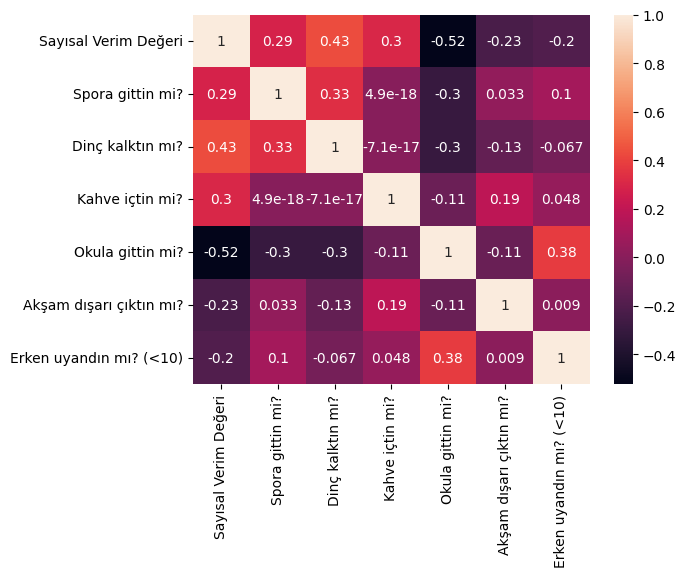

In [23]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

Korelasyon haritasında da hangi değişkenin bir diğerini nasıl *(pozitif/negatif)* etkilediğini görüyoruz.

In [26]:
import matplotlib.pyplot as plt

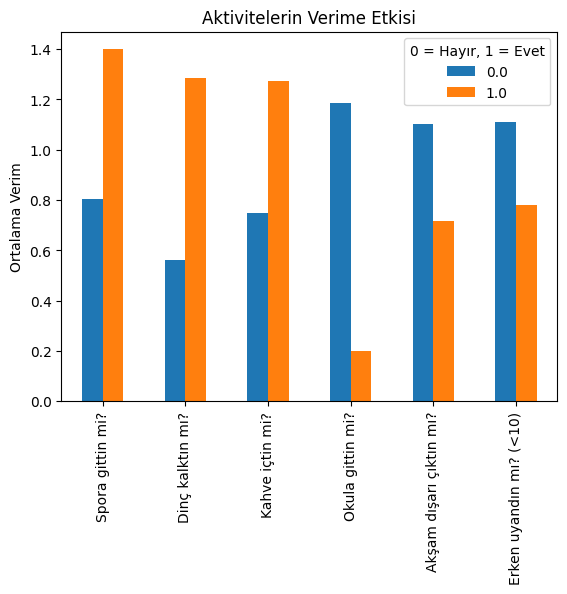

In [24]:
result = pd.DataFrame()

for col in cols:
    result[col] = df.groupby(col)['Sayısal Verim Değeri'].mean()

result.T.plot(kind='bar')

plt.title("Aktivitelerin Verime Etkisi")
plt.ylabel("Ortalama Verim")
plt.legend(title="0 = Hayır, 1 = Evet")
plt.show()

Sonuç olarak:
*   Spora gittiğim
*   Dinç kalktığım
*   Kahve içtiğim

günler verim skorunu **pozitif** etkilerken,
* okula gitmek,
* akşam dışarı çıkmak,
* erken uyanmak

verim skorunu **negatif** etkiliyor.

Ancak bu verim skorunun gösterdiği verim, **bireysel çalışma** için geçerlidir. Bu yüzden okula gitmemek daha verimlidir gibi bir çıkarım, **asla** söz konusu değildir.

Ek olarak okula gittiğim günlerde erken uyandığım için, erken uyanılan günlerin verimsiz gözükmesi normaldir.

Okula gitmediğim günlerde dinç uyanır, kahve içer ve günün herhangi bir zamanında spora gidersem o günün veriminin artacağı **bariz** bir şekilde gözükmektedir.

